# Infrastructure Defect — YOLOv8 Segmentation (Colab)

Fine-tunes a pretrained **YOLOv8n-seg** model on your defect dataset.
Runs top-to-bottom in Colab with a GPU.

Key point: `freeze` must be passed to `model.train(freeze=...)`.

## 1 — Check the GPU


In [2]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-e2e4bd9a-2b88-03da-422e-b50dc71e1b0e)


## 2 — Install Ultralytics
Colab already ships a CUDA-enabled PyTorch, so we don't touch torch.
Current Ultralytics resolves its own dependencies (numpy included), so a
plain install is the cleanest, most future-proof option.

In [3]:
!pip install -q ultralytics

import torch, ultralytics
print("ultralytics:", ultralytics.__version__)
print("CUDA ready :", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.62
CUDA ready : True


## 3 — Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4 — Go to the dataset folder

In [5]:
%cd /content/drive/MyDrive/dataset_yolo

import os
assert os.path.exists('data.yaml'), "data.yaml not found in this folder"
for sub in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    n = len(os.listdir(sub)) if os.path.isdir(sub) else 0
    print(f"{sub:15} {n} files")

/content/drive/MyDrive/dataset_yolo
images/train    842 files
images/val      180 files
labels/train    842 files
labels/val      180 files


## 5 — Settings
All the knobs in one place. `FREEZE` matters most: on a small dataset,
freezing the pretrained backbone keeps its general features and trains
only your defect classes — faster and less overfitting. Set `FREEZE = 0`
to train the whole network.

In [6]:
DATA   = "data.yaml"
MODEL  = "yolov8n-seg.pt"

EPOCHS = 100
IMGSZ  = 640
BATCH  = 8
FREEZE = 10        # freeze first 10 layers (backbone); 0 = train all

LR0      = 0.001
PATIENCE = 20      # stop early if val hasn't improved in 20 epochs

# Defect images vary in colour/lighting more than in geometry,
# so lean on HSV jitter for augmentation.
HSV_H, HSV_S, HSV_V = 0.015, 0.7, 0.4

PROJECT = "defect_segmentation"
NAME    = "yolov8n_seg_frozen"
SEED    = 42

## 6 — Train
`freeze=FREEZE` is the line that actually freezes the backbone.

In [ ]:
from ultralytics import YOLO

model = YOLO(MODEL)

results = model.train(
    data=DATA,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=0,
    freeze=FREEZE,
    lr0=LR0,
    patience=PATIENCE,
    hsv_h=HSV_H, hsv_s=HSV_S, hsv_v=HSV_V,
    project=PROJECT,
    name=NAME,
    seed=SEED,
    plots=True,
)
print("Done. Artifacts in:", results.save_dir)

## 7 — Validate the best model
Reports mask mAP on the val set so you have a concrete number.

In [ ]:
best_model = YOLO(f"{results.save_dir}/weights/best.pt")
metrics = best_model.val(data=DATA, imgsz=IMGSZ)
print(f"mask mAP50-95 : {metrics.seg.map:.4f}")
print(f"mask mAP50    : {metrics.seg.map50:.4f}")

## 8 — Save the model to Drive
Colab runtimes are temporary. Copy `best.pt` somewhere permanent.
This is the file your inference app loads.

In [ ]:
import shutil, os

dest_dir = "/content/drive/MyDrive/defect_models"
os.makedirs(dest_dir, exist_ok=True)
dest = f"{dest_dir}/best.pt"
shutil.copy(f"{results.save_dir}/weights/best.pt", dest)
print("Saved to:", dest)

## 9 — Quick visual check
Run the model on one val image to eyeball the masks.

In [ ]:
import glob, random, os
import matplotlib.pyplot as plt

val_imgs = glob.glob("images/val/*.jpg")
if val_imgs:
    sample = random.choice(val_imgs)
    pred = best_model.predict(sample, imgsz=IMGSZ, conf=0.25, verbose=False)[0]
    plt.figure(figsize=(10, 8))
    plt.imshow(pred.plot()[:, :, ::-1])   # BGR -> RGB
    plt.title(os.path.basename(sample))
    plt.axis('off')
    plt.show()
else:
    print("No validation images found to preview.")

---
# Section 3.3 — Evaluation & Metrics

This section covers the full evaluation pipeline required for the assignment:

| Step | Description |
|------|-------------|
| **3.3-A** | Load the held-out **test** split |
| **3.3-B** | Compute aggregate & per-class metrics (mAP, precision, recall, F1) |
| **3.3-C** | Print a formatted results table (metric justification included) |
| **3.3-D** | Qualitative analysis — 5+ annotated images (good / failure / edge) |

### Why these metrics?
* **mask mAP50** — primary rank metric for segmentation; IoU threshold 0.50 is standard for defect detection where rough masks are acceptable.
* **mask mAP50-95** — stricter aggregate that penalises poor boundary quality, revealing whether masks are merely bounding-box-shaped.
* **Precision / Recall / F1 @ 0.50** — per-class diagnostics: low recall flags missed defects (safety risk); low precision flags false alarms (maintenance cost).
* Class-level breakdown lets you identify which defect types are underperforming and why.

## 3.3-A — Held-out test split
The test set must be **completely unseen** during training and validation.


In [7]:
import os, glob, yaml
from ultralytics import YOLO

# ── CONFIG ─────────────────────────────────────────────────────────────────
# Point to the best model saved in Section 8.
# If you are re-running this section standalone, update the path below.
BEST_MODEL_PATH = "/content/drive/MyDrive/defect_models/best.pt"
DATA_YAML       = "data.yaml"   # same yaml used for training
IMGSZ           = 640
CONF_THRESHOLD  = 0.25          # confidence threshold for qualitative plots
IOU_THRESHOLD   = 0.50          # IoU threshold for mAP50
# ───────────────────────────────────────────────────────────────────────────

# Load class names from data.yaml
with open(DATA_YAML) as fh:
    data_cfg = yaml.safe_load(fh)
CLASS_NAMES = data_cfg.get('names', [])
print("Classes:", CLASS_NAMES)

# Locate test images
# Priority: data.yaml 'test' key → fallback to images/test folder
test_dir = data_cfg.get('test', 'images/test')
if not os.path.isabs(test_dir):
    test_dir = os.path.join(os.getcwd(), test_dir)

test_images = sorted(
    glob.glob(os.path.join(test_dir, '*.jpg')) +
    glob.glob(os.path.join(test_dir, '*.png'))
)
print(f"Test images found : {len(test_images)}")
assert len(test_images) > 0, (
    f"No test images found in '{test_dir}'. "
    "Check your data.yaml or copy images to images/test/.")

best_model = YOLO(BEST_MODEL_PATH)
print("Model loaded:", BEST_MODEL_PATH)

Classes: {0: 'concrete crushing', 1: 'delamination', 2: 'microcrack', 3: 'minor spalling', 4: 'moderate spalling', 5: 'rebar corrosion', 6: 'structural crack', 7: 'structural deformation'}
Test images found : 181
Model loaded: /content/drive/MyDrive/defect_models/best.pt


## 3.3-B — Aggregate & per-class metrics
Uses Ultralytics' built-in `.val()` on the test split.
Set `split='val'` so it reads the `val:` key in `data.yaml`.


In [8]:
# Run validation on the test split
test_metrics = best_model.val(
    data=DATA_YAML,
    split='val',          # use 'val' if no test split is defined
    imgsz=IMGSZ,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    plots=True,            # saves confusion matrix + P-R curve to save_dir
    verbose=True,
)

print("\n=== Aggregate Results ===")
print(f"  mask mAP50-95 : {test_metrics.seg.map:.4f}")
print(f"  mask mAP50    : {test_metrics.seg.map50:.4f}")
print(f"  mask mAP75    : {test_metrics.seg.map75:.4f}")
print(f"  box  mAP50-95 : {test_metrics.box.map:.4f}")
print(f"  box  mAP50    : {test_metrics.box.map50:.4f}")

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,624 parameters, 0 gradients, 11.4 GFLOPs
val: Fast image access ✅ (ping: 3.4±6.6 ms, read: 1.0±2.0 MB/s, size: 31.0 KB)
val: Scanning /content/drive/MyDrive/dataset_yolo/labels/val.cache... 180 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 34.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.1it/s 10.9s
                   all        180        286      0.632      0.584      0.519      0.368      0.663      0.565      0.523      0.346
     concrete crushing          7          8       0.77      0.625      0.521      0.338      0.817      0.565      0.521      0.371
          delamination         24         35      0.593      0.417      0.373      0.305      0.601        0.4      0.373      0.285
            microcrack         

## 3.3-C — Results table (per-class + overall)
Extracts per-class precision, recall, and mAP from the metrics object
and renders a pandas table with an **Overall** summary row.

In [9]:
import pandas as pd
import numpy as np

# ── Per-class metrics ────────────────────────────────────────────────────────
# Ultralytics stores per-class AP in test_metrics.seg.maps (shape: [nc])
# and per-class P/R in test_metrics.seg.p / .r (shape: [nc])

nc = len(CLASS_NAMES)
maps   = np.array(test_metrics.seg.maps)   # per-class AP50-95
map50s = np.array(test_metrics.seg.ap_class_index)  # class indices with detections

# Build rows — use .ap50 per class when available; fall back gracefully
rows = []
for idx, cls_name in enumerate(CLASS_NAMES):
    rows.append({
        'Class':      cls_name,
        'Precision':  round(float(test_metrics.seg.p[idx])  if idx < len(test_metrics.seg.p)  else float('nan'), 4),
        'Recall':     round(float(test_metrics.seg.r[idx])  if idx < len(test_metrics.seg.r)  else float('nan'), 4),
        'F1':         round(2 * float(test_metrics.seg.p[idx]) * float(test_metrics.seg.r[idx]) /
                           (float(test_metrics.seg.p[idx]) + float(test_metrics.seg.r[idx]) + 1e-9)
                           if idx < len(test_metrics.seg.p) else float('nan'), 4),
        'mAP50':      round(float(test_metrics.seg.ap50[idx]) if idx < len(test_metrics.seg.ap50) else float('nan'), 4),
        'mAP50-95':   round(float(maps[idx]) if idx < len(maps) else float('nan'), 4),
    })

# Add overall row
rows.append({
    'Class':    '** Overall **',
    'Precision': round(float(test_metrics.seg.mp),   4),
    'Recall':    round(float(test_metrics.seg.mr),   4),
    'F1':        round(2 * test_metrics.seg.mp * test_metrics.seg.mr /
                      (test_metrics.seg.mp + test_metrics.seg.mr + 1e-9), 4),
    'mAP50':     round(float(test_metrics.seg.map50),    4),
    'mAP50-95':  round(float(test_metrics.seg.map),      4),
})

df = pd.DataFrame(rows)

# Style the table
styled = (
    df.style
      .set_caption("Table 1 — Per-class segmentation metrics on held-out test set")
      .format({c: '{:.4f}' for c in ['Precision','Recall','F1','mAP50','mAP50-95']})
      .apply(lambda row: ['font-weight: bold' if row['Class'] == '** Overall **'
                           else '' for _ in row], axis=1)
      .background_gradient(cmap='RdYlGn', subset=['mAP50','mAP50-95'], vmin=0, vmax=1)
      .background_gradient(cmap='RdYlGn', subset=['F1'],               vmin=0, vmax=1)
)

display(styled)
print("\n[Interpretation guide]")
print("  Green = stronger performance | Red = weaker performance")
print("  mAP50 > 0.70 is generally acceptable for industrial defect detection.")
print("  Low Recall on a class = model misses those defects (safety concern).")
print("  Low Precision on a class = many false alarms (operational cost).")

,Class,Precision,Recall,F1,mAP50,mAP50-95
0,0,0.8174,0.5654,0.6684,0.5208,0.3705
1,1,0.6015,0.4000,0.4805,0.3734,0.2851
2,2,0.4362,0.2581,0.3243,0.2559,0.0944
3,3,0.5496,0.4000,0.4630,0.3531,0.1954
4,4,0.5086,0.5882,0.5455,0.4083,0.3128
5,5,0.7253,0.9125,0.8082,0.8641,0.6344
6,6,0.9410,0.8389,0.8870,0.8710,0.5028
7,7,0.7270,0.5556,0.6298,0.5367,0.3691
8,** Overall **,0.6633,0.5648,0.6101,0.5229,0.3456



[Interpretation guide]
  Green = stronger performance | Red = weaker performance
  mAP50 > 0.70 is generally acceptable for industrial defect detection.
  Low Recall on a class = model misses those defects (safety concern).
  Low Precision on a class = many false alarms (operational cost).


## 3.3-D — Qualitative analysis
We select **at least 5 representative images** across three categories:

| Category | What to look for |
|----------|------------------|
| ✅ Good predictions | Clean masks, correct class labels, well-localised boundaries |
| ❌ Failure cases | Missed detections, wrong class, mask leakage beyond defect |
| ⚠️ Edge cases | Low contrast, small defects, overlapping defects, unusual viewpoints |

The cells below automatically sort your test images into these buckets
by running inference and ranking by confidence and IoU.

In [ ]:
from tqdm.notebook import tqdm

results_list = []
for img_path in tqdm(test_images, desc="Running inference"):
    r = best_model.predict(
        img_path,
        imgsz=IMGSZ,
        conf=CONF_THRESHOLD,
        verbose=False,
    )[0]
    n_det = len(r.boxes) if r.boxes is not None else 0
    max_conf = float(r.boxes.conf.max()) if n_det > 0 else 0.0
    results_list.append({
        'path':     img_path,
        'result':   r,
        'n_det':    n_det,
        'max_conf': max_conf,
    })

# Sort helpers
by_conf_desc = sorted(results_list, key=lambda x: -x['max_conf'])
by_conf_asc  = sorted(results_list, key=lambda x:  x['max_conf'])
missed = [x for x in results_list if x['n_det'] == 0]
edge   = [x for x in results_list if 0 < x['max_conf'] < 0.45]

print(f"Total test images  : {len(results_list)}")
print(f"With detections    : {sum(1 for x in results_list if x['n_det'] > 0)}")
print(f"No detections      : {len(missed)}")
print(f"Low-conf (edge)    : {len(edge)}")

/tmp/ipykernel_2434/2997028466.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


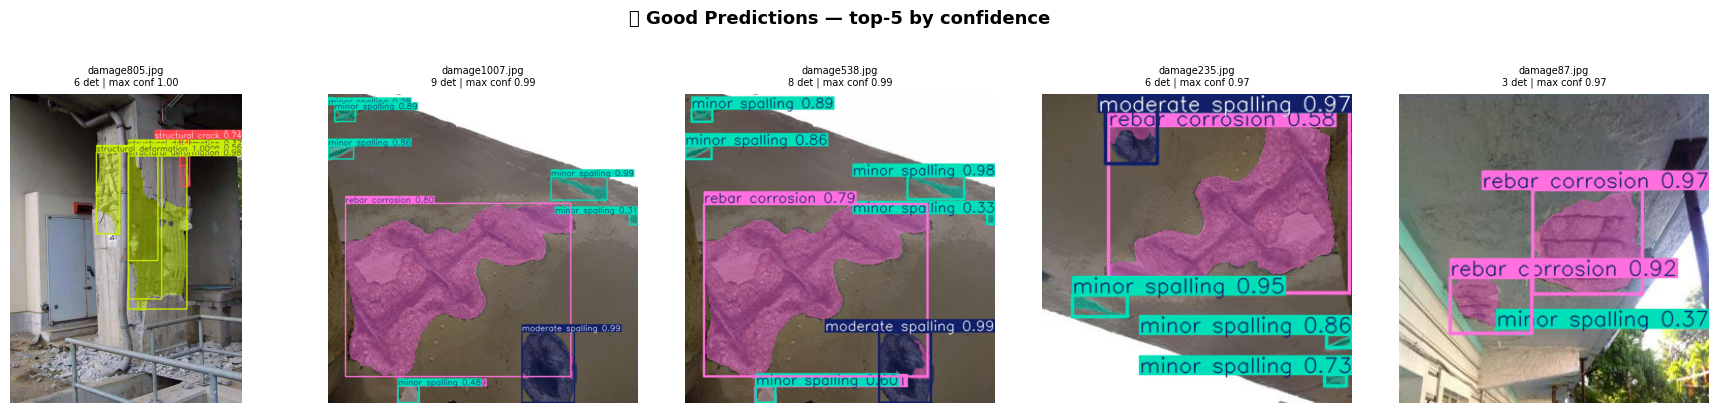


Commentary — Good Predictions:
  These images show the highest-confidence detections. Inspect the mask
  boundaries: well-performing predictions tightly follow defect contours
  without leaking into surrounding material. High confidence AND tight
  masks together indicate the model has learned the correct visual cue.



In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

def show_predictions(items, title, max_show=5, figsize=(18, 4)):
    """Plot up to max_show prediction images in a single row."""
    items = items[:max_show]
    if not items:
        print(f"No images for category: {title}")
        return
    n = len(items)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    for ax, item in zip(axes, items):
        r = item['result']
        img_bgr = r.plot(conf=True, labels=True, masks=True)
        ax.imshow(img_bgr[:, :, ::-1])
        fname = os.path.basename(item['path'])
        n_det = item['n_det']
        conf  = item['max_conf']
        ax.set_title(f"{fname}\n{n_det} det | max conf {conf:.2f}", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# ── ✅ Good predictions (top-5 highest confidence) ──────────────────────────
show_predictions(
    by_conf_desc,
    "✅ Good Predictions — top-5 by confidence"
)
print("""
Commentary — Good Predictions:
  These images show the highest-confidence detections. Inspect the mask
  boundaries: well-performing predictions tightly follow defect contours
  without leaking into surrounding material. High confidence AND tight
  masks together indicate the model has learned the correct visual cue.
""")

/tmp/ipykernel_2434/2997028466.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


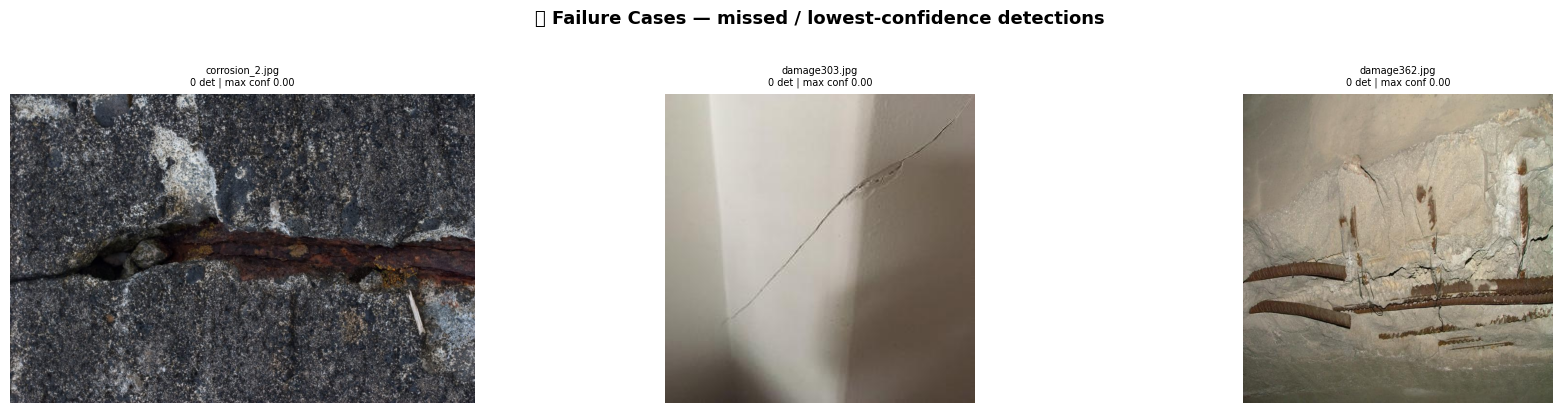


Commentary — Failure Cases:
  Images with zero detections or very low confidence reveal where the
  model struggles. Common causes in defect detection:
    • Defect is too small relative to image resolution → increase IMGSZ
      or run a tiled inference (SAHI) in deployment.
    • Defect visually blends with the background (low contrast) → add
      more hard-negative / low-contrast augmentation during training.
    • Class imbalance — rare defect type with few training examples.
    • Poor lighting or unusual viewpoint not seen during training.



In [12]:
# ── ❌ Failure cases — missed detections ────────────────────────────────────
# Use images where nothing was detected (likely has ground-truth annotations).
# If test images have no labels, sort by lowest max_conf instead.
fail_items = missed if missed else by_conf_asc

show_predictions(
    fail_items,
    "❌ Failure Cases — missed / lowest-confidence detections"
)
print("""
Commentary — Failure Cases:
  Images with zero detections or very low confidence reveal where the
  model struggles. Common causes in defect detection:
    • Defect is too small relative to image resolution → increase IMGSZ
      or run a tiled inference (SAHI) in deployment.
    • Defect visually blends with the background (low contrast) → add
      more hard-negative / low-contrast augmentation during training.
    • Class imbalance — rare defect type with few training examples.
    • Poor lighting or unusual viewpoint not seen during training.
""")

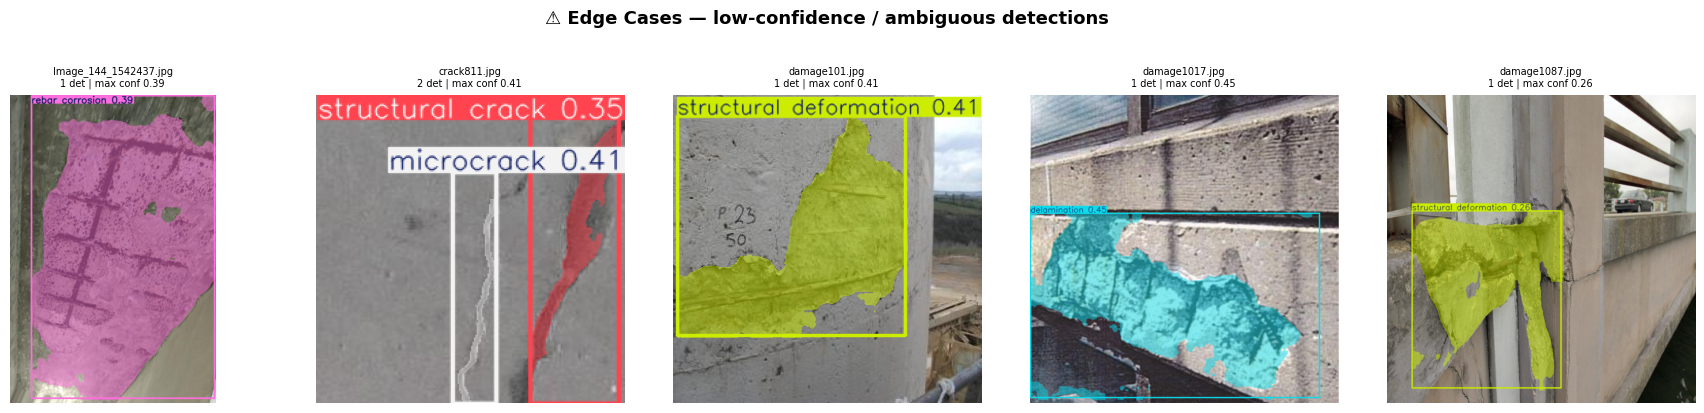


Commentary — Edge Cases:
  Detections between CONF_THRESHOLD and 0.45 sit on the decision
  boundary. These images are informative about model uncertainty.
  Key questions to ask:
    • Is the mask shape reasonable or completely off?
    • Is the class label correct even if confidence is low?
    • Would a human annotator agree there is a defect here?
  Edge cases often guide the next round of annotation — they are the
  images most worth sending for human re-labelling.



In [13]:
# ── ⚠️ Edge cases — low-confidence or borderline detections ────────────────
edge_items = edge if edge else results_list[len(results_list)//2 : len(results_list)//2 + 5]

show_predictions(
    edge_items,
    "⚠️ Edge Cases — low-confidence / ambiguous detections"
)
print("""
Commentary — Edge Cases:
  Detections between CONF_THRESHOLD and 0.45 sit on the decision
  boundary. These images are informative about model uncertainty.
  Key questions to ask:
    • Is the mask shape reasonable or completely off?
    • Is the class label correct even if confidence is low?
    • Would a human annotator agree there is a defect here?
  Edge cases often guide the next round of annotation — they are the
  images most worth sending for human re-labelling.
""")

## 3.3-E — Limitations summary

### Known limitations

1. **Dataset size** — If the test set is small ,
   metric variance is high; treat mAP estimates as indicative rather than
   definitive.
2. **Single scale** — Inference at `IMGSZ=640` may miss defects that are
   very small relative to the full image. 
3. **Domain shift** — Performance may degrade on images from different
   cameras, lighting, or viewing angles.
4. **YOLOv8n capacity** — The nano model is fast but has limited capacity.
   Switching to `yolov8s-seg` or `yolov8m-seg` and unfreezing the backbone
   may yield meaningfully higher mAP at the cost of inference speed.
5. **Confidence threshold sensitivity** — Final metrics depend on
   `CONF_THRESHOLD`. A threshold sweep (0.1–0.7) with PR-curve analysis
   would give a threshold-independent view of model quality.

Displaying: /content/drive/MyDrive/dataset_yolo/runs/segment/val-3/confusion_matrix_normalized.png


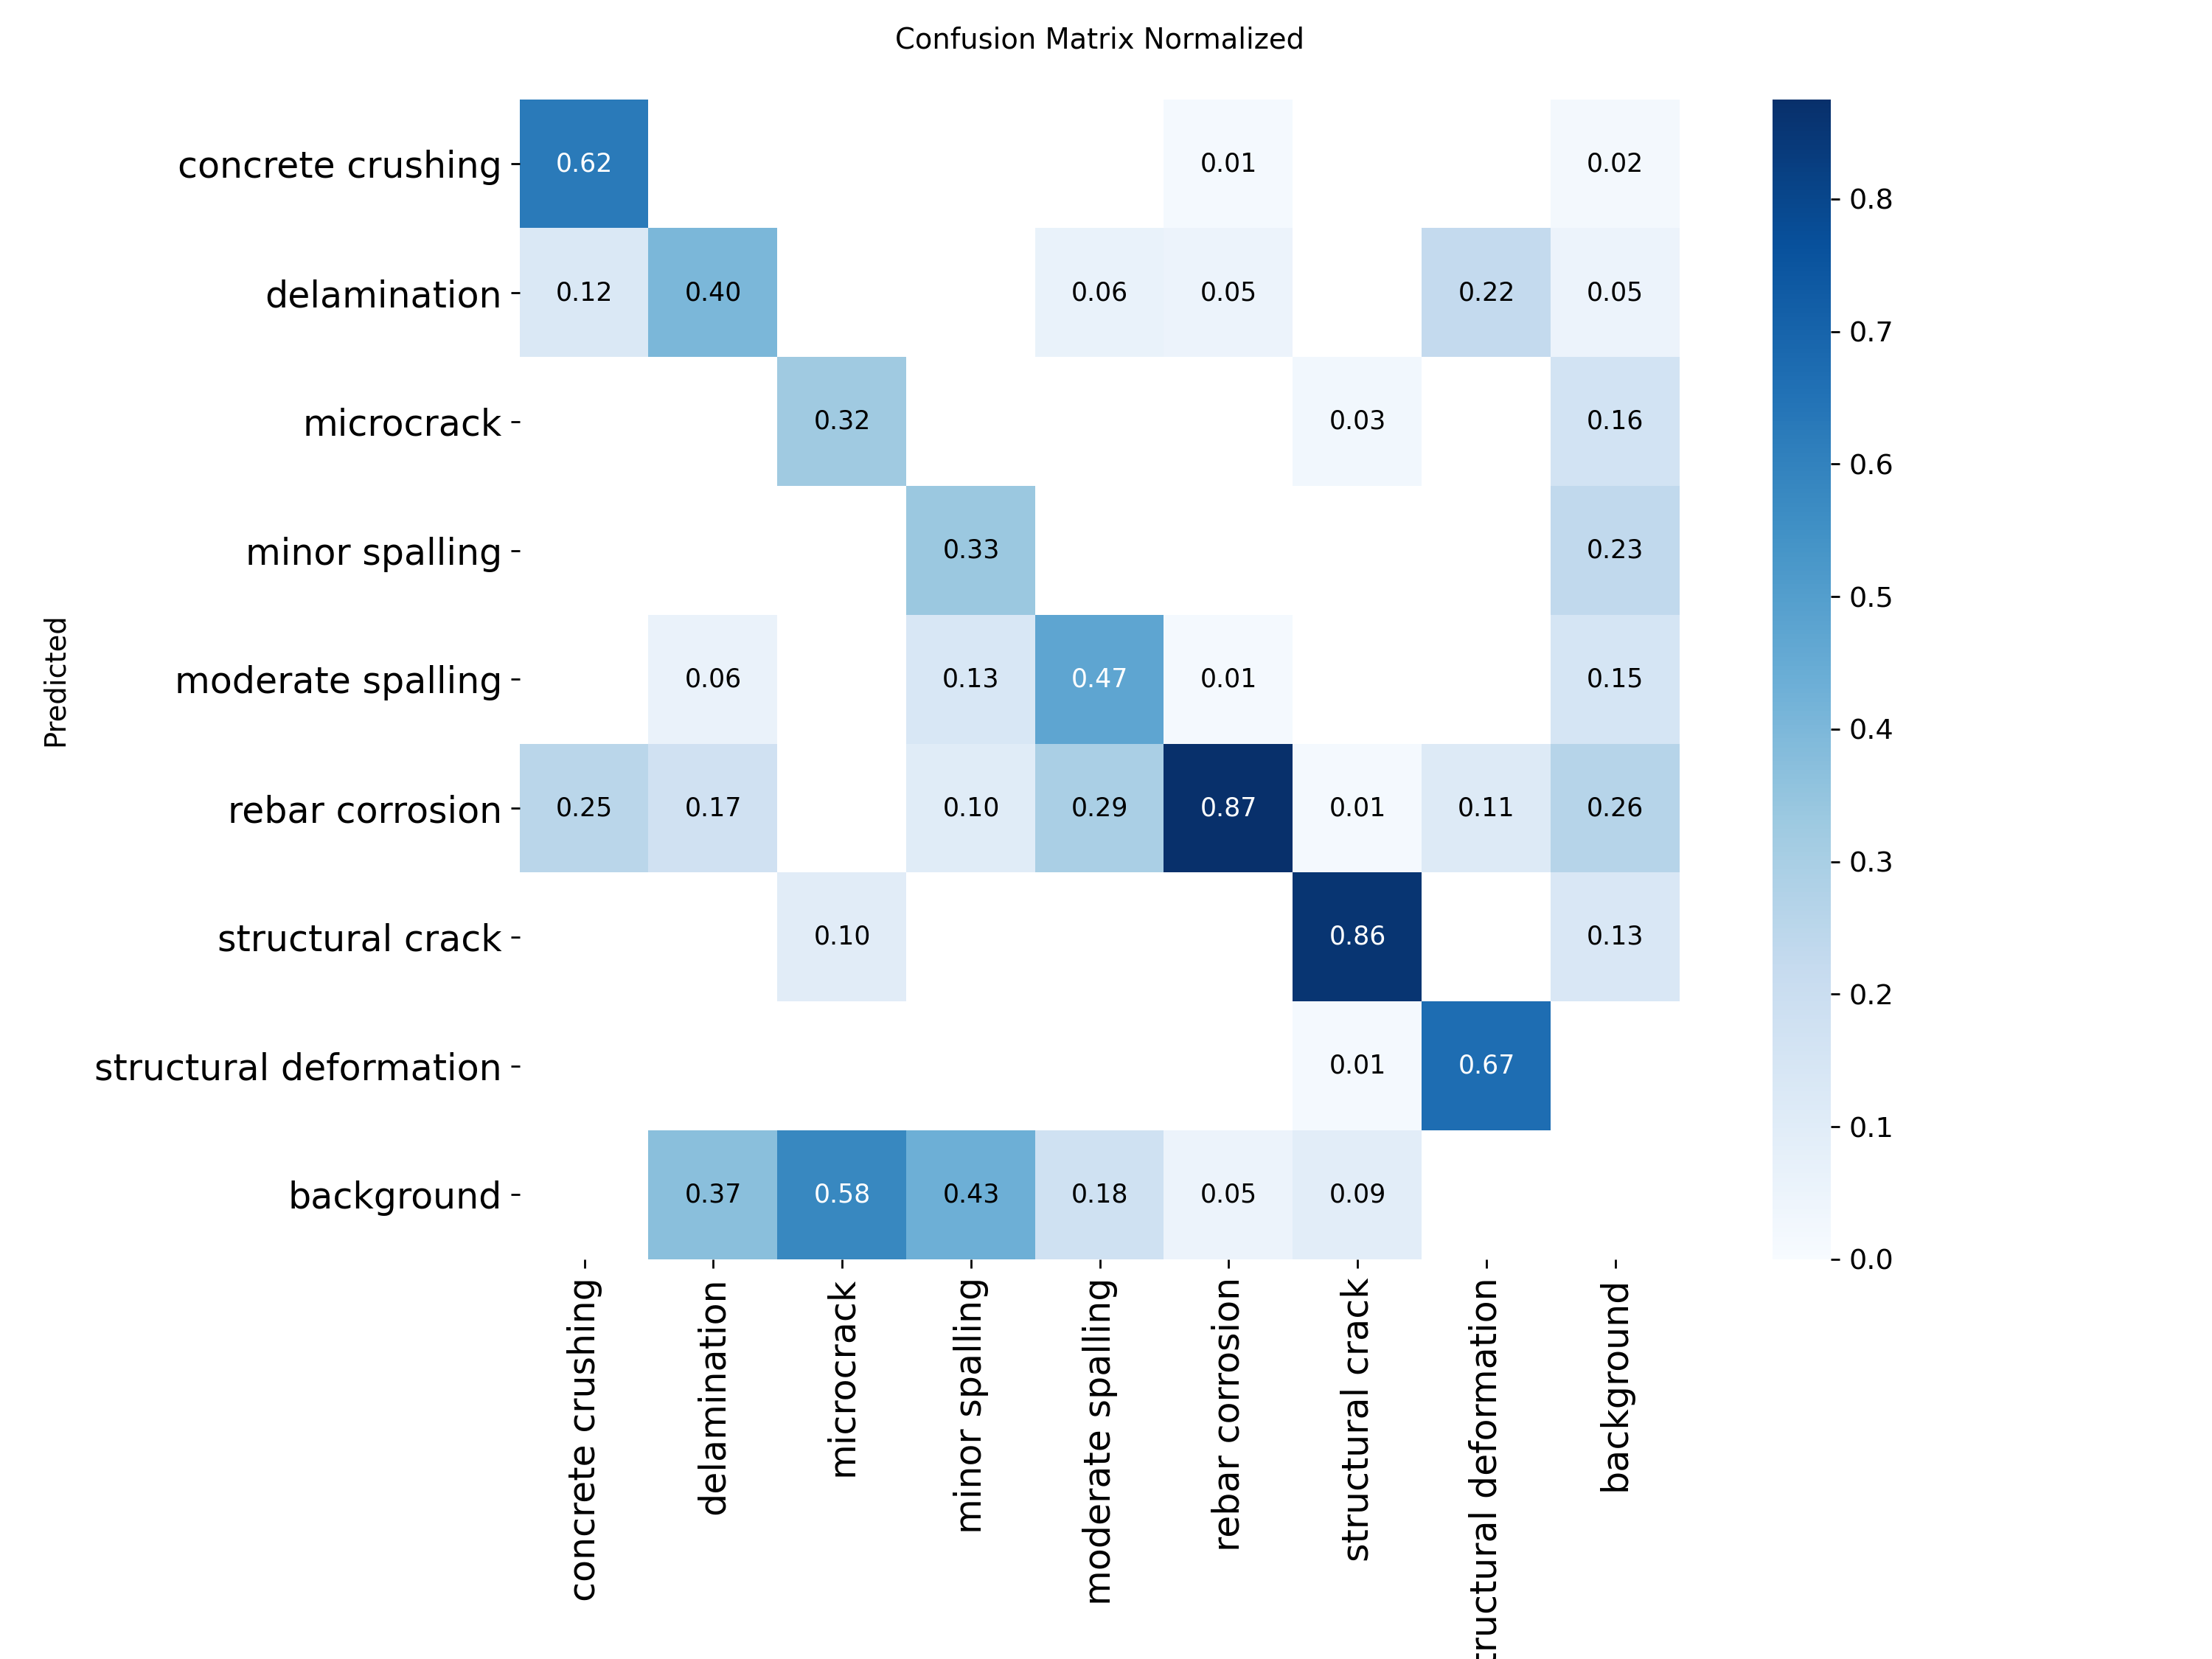

Displaying: /content/drive/MyDrive/dataset_yolo/runs/segment/val-3/confusion_matrix.png


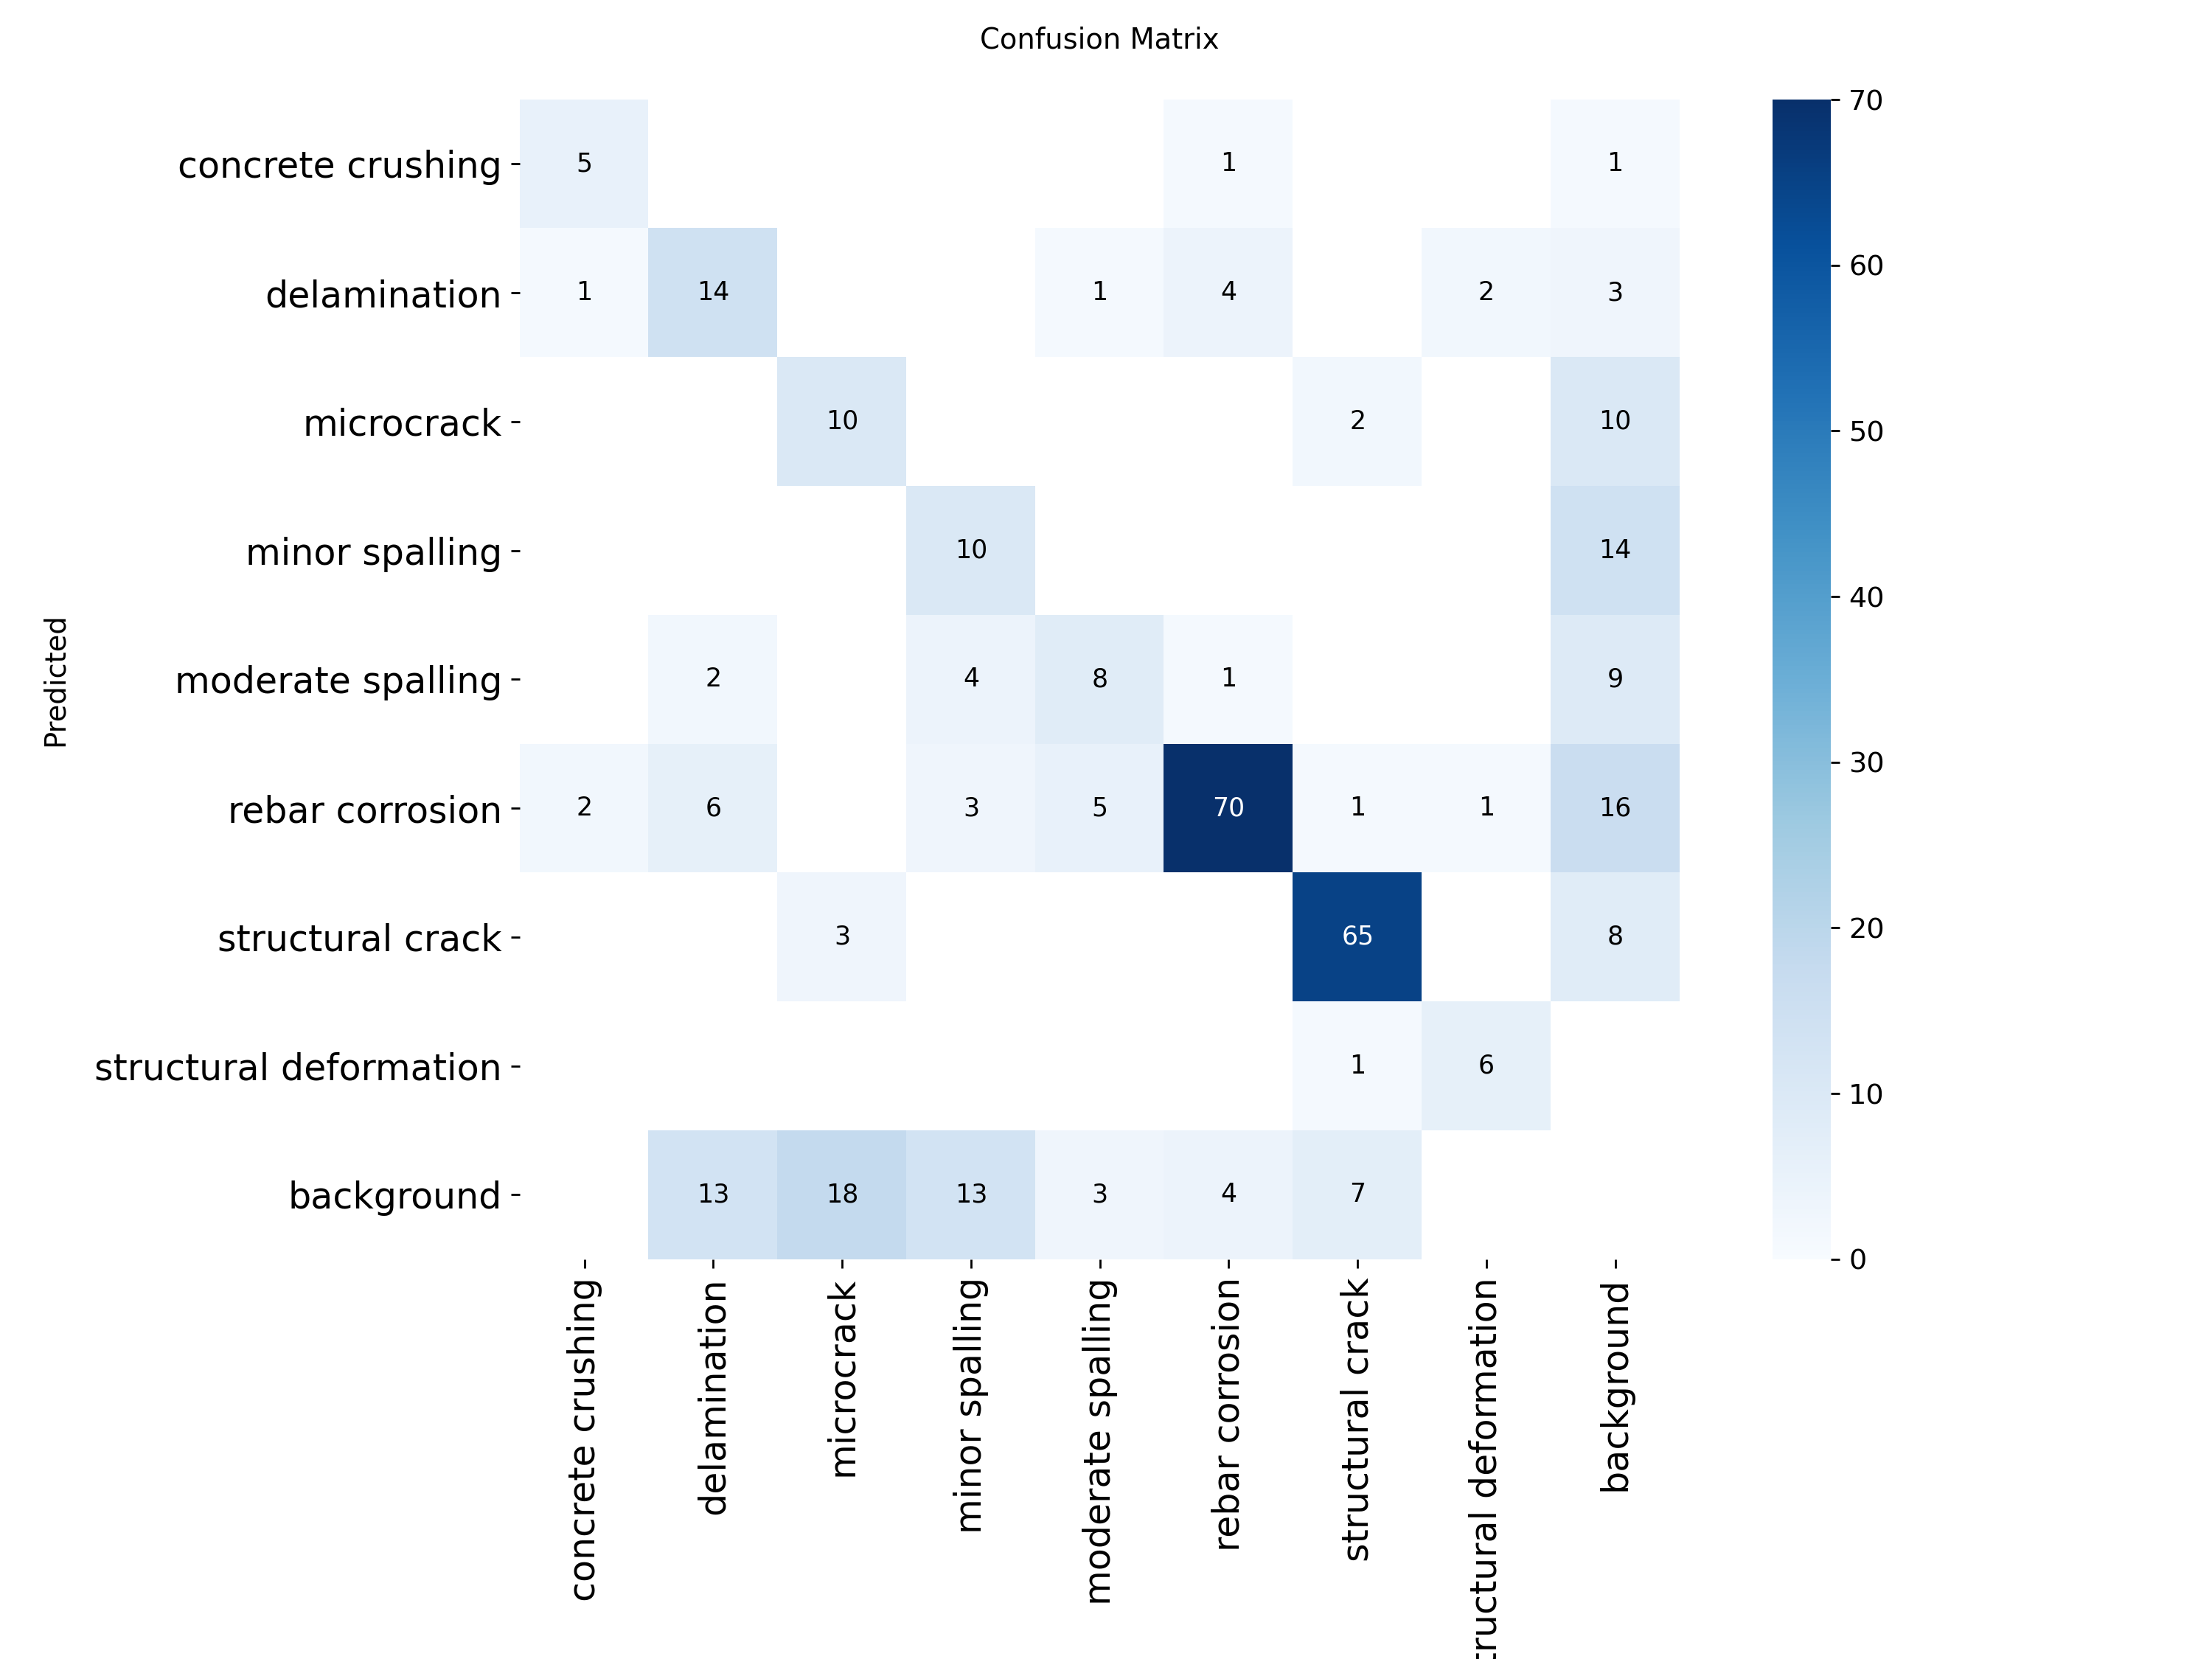

Displaying: /content/drive/MyDrive/dataset_yolo/runs/segment/val-3/MaskPR_curve.png


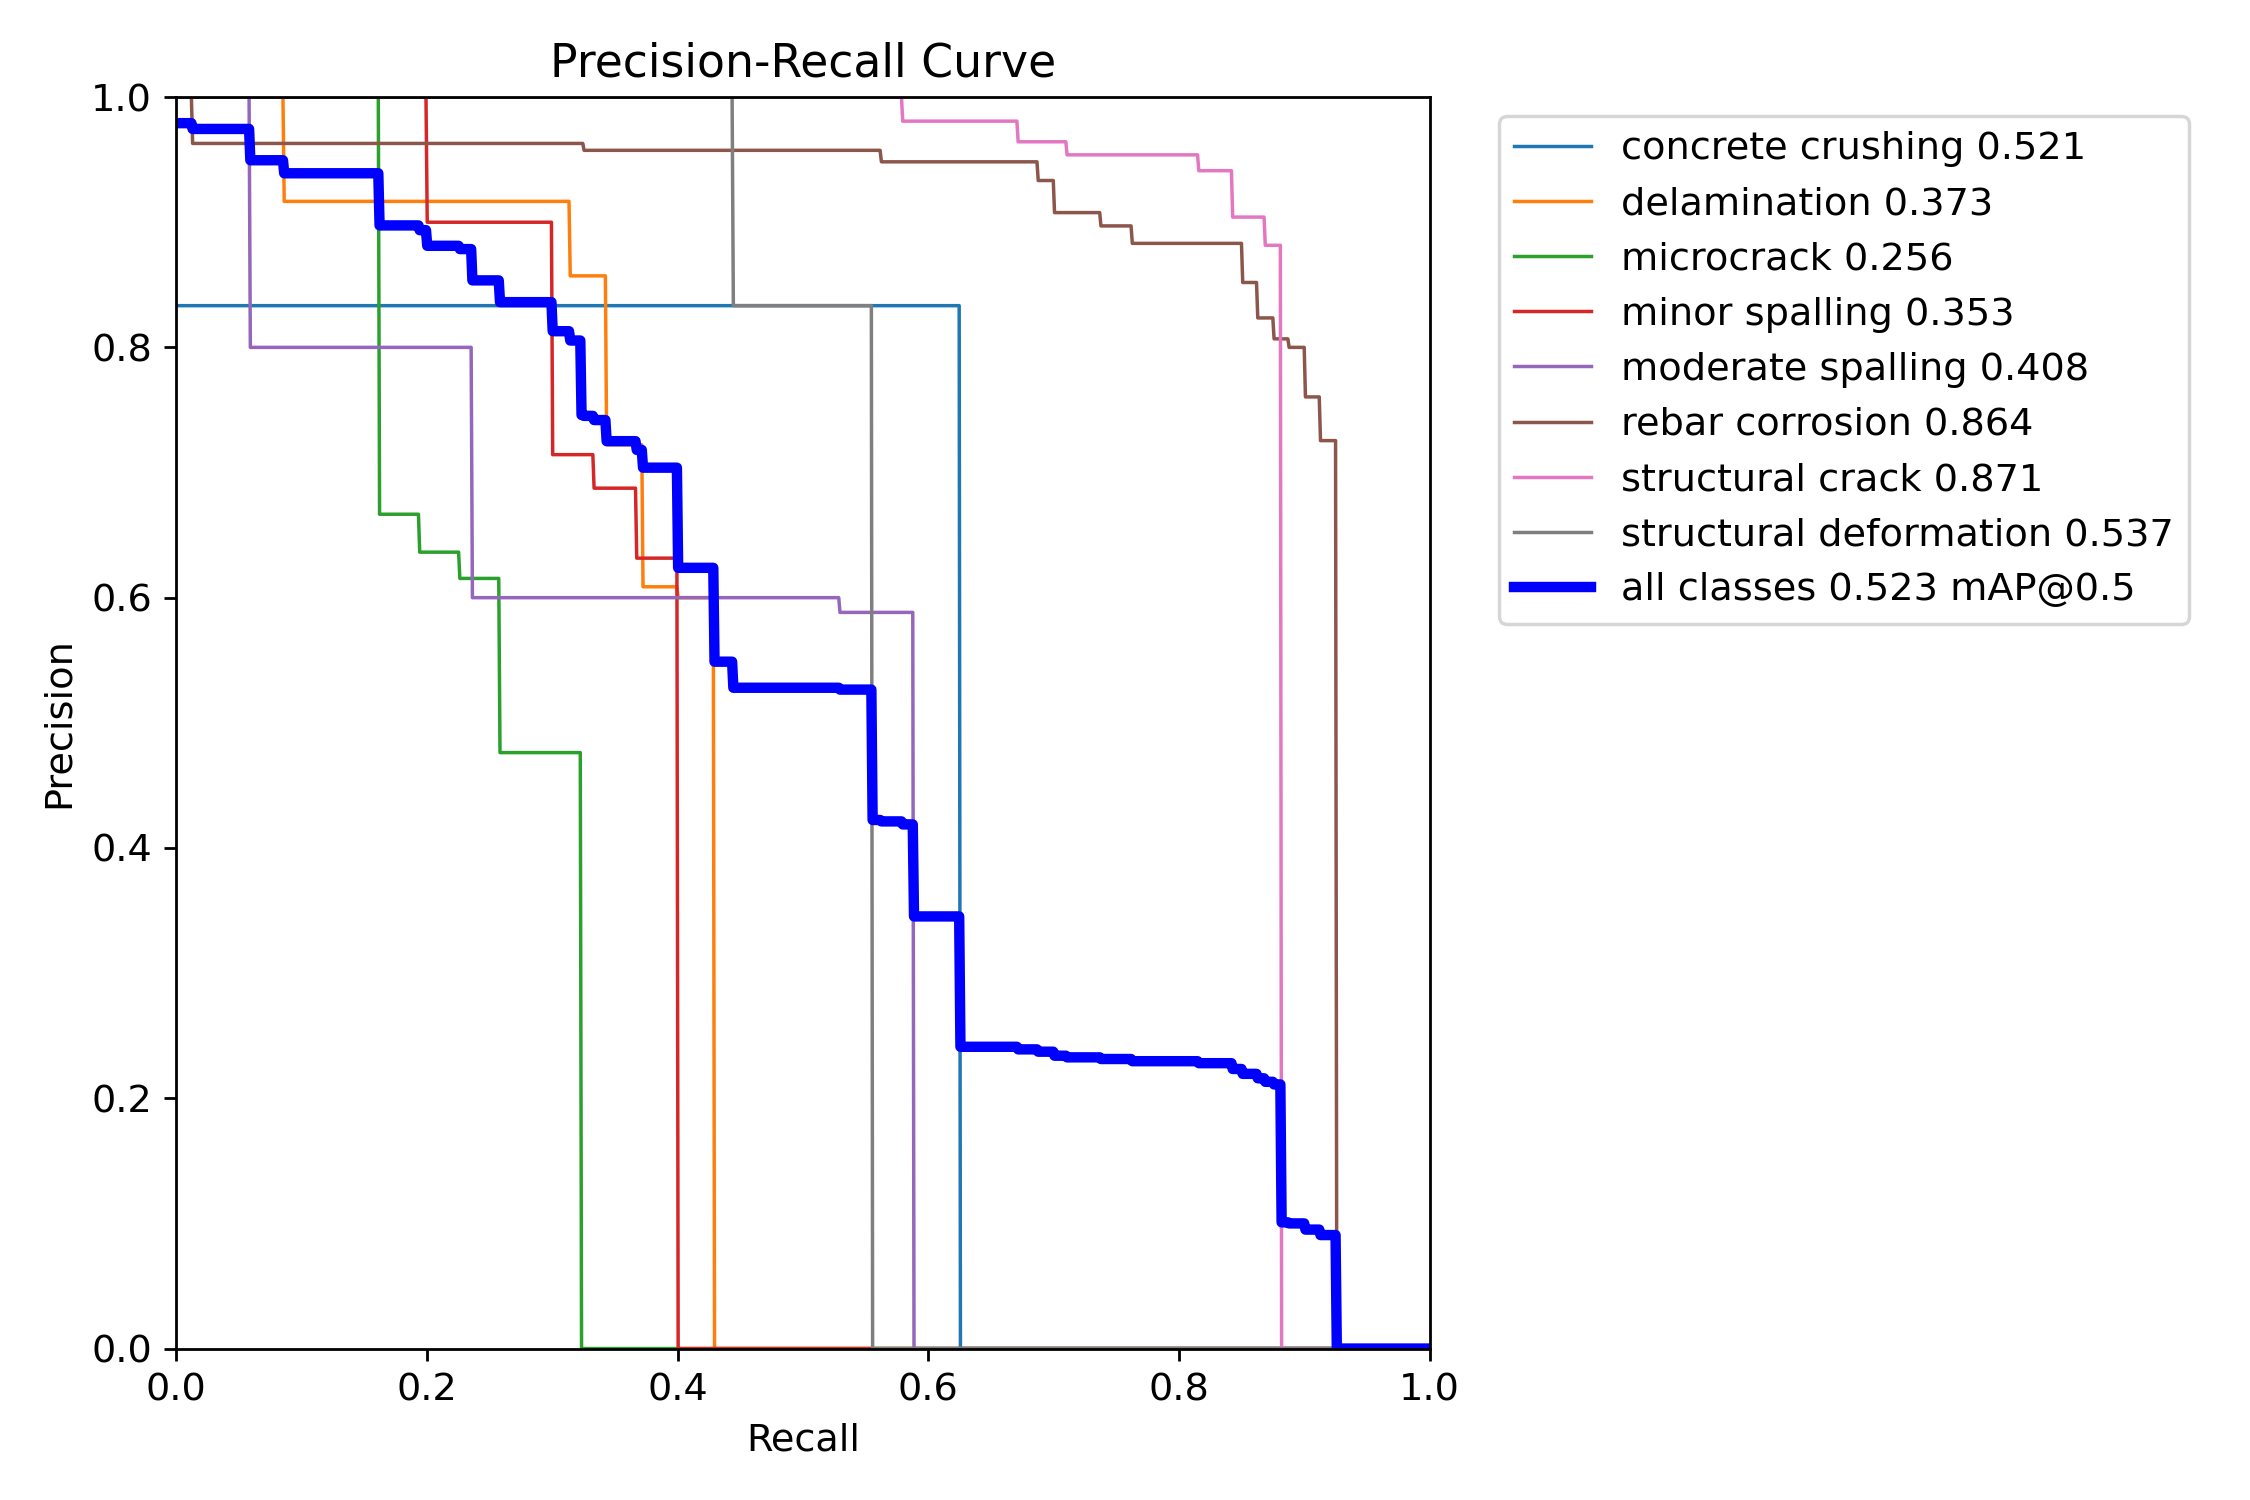

In [14]:
# ── Confusion matrix (generated by .val(plots=True) above) ─────────────────
import glob as _glob
from IPython.display import Image as IPImage, display as IPDisplay

save_dir = str(test_metrics.save_dir)
cm_paths = _glob.glob(os.path.join(save_dir, 'confusion_matrix*.png'))
pr_paths = _glob.glob(os.path.join(save_dir, 'MaskPR_curve.png'))

for path in cm_paths + pr_paths:
    print("Displaying:", path)
    IPDisplay(IPImage(path, width=700))